In [ ]:
from tinkoff.invest import Client, AsyncClient, CandleInterval, SecurityTradingStatus, InstrumentStatus
from tinkoff.invest.services import InstrumentsService
from tinkoff.invest.utils import quotation_to_decimal, now
from tinkoff.invest.caching.instruments_cache.instruments_cache import InstrumentsCache

from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_fscore_support

import pyarrow
import shutil
import pywt
import pandas as pd
from pandas.tseries.offsets import DateOffset
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import math

import time
from datetime import datetime, timezone, timedelta

from pathlib import Path
from typing import Dict, List, Tuple, Optional

from dotenv import load_dotenv

import warnings
warnings.filterwarnings("ignore")

In [39]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

In [40]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

In [41]:
load_dotenv()

TOKEN = os.getenv("TOKEN")

In [71]:
TRAIN_MONTHS = 48  
TEST_MONTHS = 1    
WINDOW_SIZE = 24   
ALPHA = 1.0
LEARNING_RATE = 0.0001
CONFIDENCE_THRESHOLD = 0.75
MIN_HOLD_BARS = 6
TICKERS = ['SBER', 'MGNT', 'VTBR', 'TATN', 'LKOH', 'YDEX', 'GLDRUB_TOM']

In [ ]:
def add_technical_indicators(df: pd.DataFrame,
                             sma_periods: list = [20, 50, 200],
                             ema_periods: list = [12, 26],
                             rsi_period: int = 14,
                             macd_fast: int = 12,
                             macd_slow: int = 26,
                             macd_signal: int = 9,
                             bb_period: int = 20,
                             cci_period: int = 20,
                             adx_period: int = 14,
                             roc_period: int = 12,
                             cmf_period: int = 20) -> pd.DataFrame:
    df = df.copy()
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']

    # --- LAGGING INDICATORS ---
    for period in sma_periods:
        df[f'SMA_{period}'] = close.rolling(window=period).mean()
    for period in ema_periods:
        df[f'EMA_{period}'] = close.ewm(span=period, adjust=False).mean()

    ema_f = close.ewm(span=macd_fast, adjust=False).mean()
    ema_s = close.ewm(span=macd_slow, adjust=False).mean()
    df['MACD'] = ema_f - ema_s
    df['MACD_Signal'] = df['MACD'].ewm(span=macd_signal, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

    sma_bb = close.rolling(window=bb_period).mean()
    std_bb = close.rolling(window=bb_period).std()
    df['BB_Upper'] = sma_bb + (2 * std_bb)
    df['BB_Lower'] = sma_bb - (2 * std_bb)

    # --- LEADING INDICATORS ---
    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=rsi_period).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    tp = (high + low + close) / 3
    sma_tp = tp.rolling(window=cci_period).mean()
    mad_tp = tp.rolling(window=cci_period).apply(lambda x: np.abs(x - x.mean()).mean())
    df['CCI'] = (tp - sma_tp) / (0.015 * mad_tp)

    # ИСПРАВЛЕНО: VWAP, OBV, ADL теперь сбрасываются каждый день (группировка по дате)
    df['Date'] = pd.to_datetime(df['DateTime']).dt.date
    
    # VWAP
    df['Typical_Price_Vol'] = volume * (high + low + close) / 3
    df['Cum_TP_Vol'] = df.groupby('Date')['Typical_Price_Vol'].cumsum()
    df['Cum_Vol'] = df.groupby('Date')['Volume'].cumsum()
    df['VWAP'] = df['Cum_TP_Vol'] / df['Cum_Vol']
    df.drop(['Typical_Price_Vol', 'Cum_TP_Vol', 'Cum_Vol'], axis=1, inplace=True)

    # OBV
    obv_sign = np.sign(close.diff())
    df['OBV_Raw'] = (obv_sign * volume).fillna(0)
    df['OBV'] = df.groupby('Date')['OBV_Raw'].cumsum()
    df.drop('OBV_Raw', axis=1, inplace=True)

    # ADX
    plus_dm = high.diff().where((high.diff() > low.diff().abs()) & (high.diff() > 0), 0)
    minus_dm = low.diff().abs().where((low.diff().abs() > high.diff()) & (low.diff().abs() > 0), 0)
    tr = pd.concat([high - low, (high - close.shift()).abs(), (low - close.shift()).abs()], axis=1).max(axis=1)
    atr = tr.rolling(window=adx_period).mean()
    plus_di = 100 * (plus_dm.rolling(window=adx_period).mean() / atr)
    minus_di = 100 * (minus_dm.rolling(window=adx_period).mean() / atr)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    df['ADX'] = dx.rolling(window=adx_period).mean()

    # ADL
    mfm = ((close - low) - (high - close)) / (high - low)
    mfm = mfm.replace([np.inf, -np.inf], 0).fillna(0)
    df['MFL_Vol'] = mfm * volume
    df['ADL'] = df.groupby('Date')['MFL_Vol'].cumsum()
    df.drop('MFL_Vol', axis=1, inplace=True)

    # CMF
    df['CMF'] = df['MFL_Vol'].rolling(window=cmf_period).sum() / volume.rolling(window=cmf_period).sum() # Ошибка: MFL_Vol уже удален. Исправляю ниже:
    mfv = mfm * volume
    df['CMF'] = mfv.rolling(window=cmf_period).sum() / volume.rolling(window=cmf_period).sum()

    # --- NEUTRAL / MOMENTUM INDICATORS ---
    df['ROC'] = ((close - close.shift(roc_period)) / close.shift(roc_period)) * 100

    df.drop('Date', axis=1, inplace=True) # Удаляем временный столбец
    return df

In [ ]:
def build_model(input_shape):
    model = models.Sequential([
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax') 
    ])
    
    try:
        opt = optimizers.legacy.Adam(learning_rate=LEARNING_RATE)
    except AttributeError:
        opt = optimizers.Adam(learning_rate=LEARNING_RATE)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def create_tensors(df, window_size=WINDOW_SIZE, alpha=ALPHA, feature_cols=None):
    df = df.copy().sort_values("DateTime")
    
    # Расчет таргета
    returns = df['Close'].pct_change()
    volatility = returns.rolling(window=10).std()
    future_change = (df['Close'].shift(-window_size) - df['Close']) / df['Close']
    
    conditions = [
        (future_change >= alpha * volatility), # Up (1)
        (future_change <= -alpha * volatility) # Down (2)
    ]
    df['Target'] = np.select(conditions, [1, 2], default=0) # Flat (0)
    
    if feature_cols is None:
        feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
        
    data_x = df[feature_cols].values
    data_y = df['Target'].values
    dates = df['DateTime'].values
    prices = df['Close'].values

    X, y, out_dates, out_prices = [], [], [], []

    for i in range(window_size, len(df) - window_size):
        window = data_x[i-window_size:i]
        
        # Локальная нормализация окна 
        # Важно: для осцилляторов типа RSI Z-score может быть странноват, но для CNN это стабилизирует вход
        scaler = StandardScaler()
        norm_window = scaler.fit_transform(window)
        
        if np.isnan(norm_window).any():
            continue
            
        X.append(norm_window)
        y.append(data_y[i])
        out_dates.append(dates[i])
        out_prices.append(prices[i])

    return np.array(X), np.array(y), np.array(out_dates), np.array(out_prices), feature_cols

In [ ]:
def wavelet_denoise_5m_safe(series, wavelet='sym4', level=3, daily_window=78):
    """
    Каузальный вейвлет-денойзинг без NaN/Inf артефактов.
    """
    n = len(series)
    values = series.values.astype(float)
    denoised = np.full(n, np.nan)

    denoised[:daily_window] = values[:daily_window]

    for i in range(daily_window, n):
        chunk = values[i-daily_window:i]
        # mode='constant' безопаснее для финансовых рядов
        coeffs = pywt.wavedec(chunk, wavelet, mode='constant', level=level)
        
        # Donoho/MAD порог
        sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        uthresh = sigma * np.sqrt(2 * np.log(daily_window))
        
        denoised_coeffs = [pywt.threshold(c, uthresh, mode='soft') for c in coeffs]
        
        # Реконструкция + защита от сдвига длины
        rec = pywt.waverec(denoised_coeffs, wavelet, mode='constant')
        denoised[i] = rec[-1]  # Берём только текущую точку

    result = pd.Series(denoised, index=series.index, name=series.name)
    result = result.ffill().bfill()
    result = result.replace([np.inf, -np.inf], np.nan).ffill()
    return result

In [ ]:
def fill_time_gaps(df: pd.DataFrame, interval_name: str = "5min") -> pd.DataFrame:
    resample_map = {"5min": "5T", "15min": "15T", "1hour": "H", "1day": "D"}
    freq = resample_map.get(interval_name, "5T")
    
    df = df.copy()
    
    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime')
    elif not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame должен иметь колонку 'DateTime' или DatetimeIndex")
    
    df = df.sort_index()
    
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    df = df.reindex(full_range)
    df.index.name = "DateTime"
    
    price_cols = ['Open', 'High', 'Low', 'Close']
    df[price_cols] = df[price_cols].ffill().bfill()
    if 'Volume' in df.columns:
        df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index()

In [ ]:
def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    if 'DateTime' in df.columns:
        df = df.set_index('DateTime').sort_index()
    elif isinstance(df.index, pd.DatetimeIndex):
        df = df.sort_index()
        if df.index.name is None:
            df.index.name = 'DateTime'
    else:
        raise ValueError("Нет колонки или индекса DateTime")
    
    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    
    for col in cols_to_fix:
        if col in df.columns:
            df[col] = df[col].replace(0, pd.NA)
    
    df[cols_to_fix] = df[cols_to_fix].ffill()
    df[cols_to_fix] = df[cols_to_fix].bfill()
    
    if 'Volume' in df.columns:
        df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index()

In [ ]:
def run_backtest_with_fine_tuning(df, ticker_name, alpha, confidence_threshold, 
                                   save_plots=False, best_config=False):
    
    if save_plots:
        os.makedirs(f"results/plots/{ticker_name}", exist_ok=True)
        os.makedirs(f"results/metrics/{ticker_name}", exist_ok=True)
    
    total_months = (df['DateTime'].max() - df['DateTime'].min()).days // 30
    if total_months < TRAIN_MONTHS + TEST_MONTHS:
        print(f"⚠️ {ticker_name}: Недостаточно данных!")
        return pd.DataFrame(), {}
    
    cols_to_exclude = ['DateTime', 'Target', 'index']
    feature_cols = [c for c in df.columns if c not in cols_to_exclude]
    
    X_all, y_all, dates_all, prices_all, used_features = create_tensors(df, alpha=alpha, feature_cols=feature_cols) 
    
    if len(X_all) == 0:
        return pd.DataFrame(), {}
        
    dt_index = pd.to_datetime(dates_all)
    start_date = dt_index.min()
    current_test_start = start_date + DateOffset(months=TRAIN_MONTHS)
    
    num_features = X_all.shape[2]
    model = build_model(input_shape=(WINDOW_SIZE, num_features))
    
    initial_mask = (dt_index >= start_date) & (dt_index < current_test_start)
    if initial_mask.sum() < 10:
        return pd.DataFrame(), {}
    
    # Вычисляем веса классов для борьбы с дисбалансом (много Flat, мало Buy/Sell)    
    X_train_init, y_train_init = X_all[initial_mask], y_all[initial_mask]
    classes = np.unique(y_train_init)
    weights = compute_class_weight('balanced', classes=classes, y=y_train_init)
    class_weight_dict = dict(zip(classes, weights))
    
    print(f"Обучение {ticker_name} на {initial_mask.sum()} семплах. Веса классов: {class_weight_dict}")
    model.fit(X_train_init, y_train_init, epochs=15, batch_size=32, verbose=0, class_weight=class_weight_dict)
    
    all_preds = []
    all_metrics = []
    
    while current_test_start < dt_index.max():
        test_end = current_test_start + DateOffset(months=TEST_MONTHS)
        test_mask = (dt_index >= current_test_start) & (dt_index < test_end)
        
        X_test, y_test = X_all[test_mask], y_all[test_mask]
        if len(X_test) == 0: 
            current_test_start = test_end
            continue
            
        probs = model.predict(X_test, verbose=0)
        
        final_classes = []
        confident_mask = []
        for p in probs:
            is_confident = (p[1] > confidence_threshold) or (p[2] > confidence_threshold)
            confident_mask.append(is_confident)
            if p[1] > confidence_threshold:
                final_classes.append(1)
            elif p[2] > confidence_threshold:
                final_classes.append(2)
            else:
                final_classes.append(0)
        
        confident_mask = np.array(confident_mask)
        final_classes = np.array(final_classes)
        
        chunk_metrics = {
            'ticker': ticker_name, 'alpha': alpha, 'confidence_threshold': confidence_threshold,
            'period_start': current_test_start, 'period_end': test_end,
            'total_samples': len(y_test), 'confident_samples': int(confident_mask.sum()),
            'confident_ratio': float(confident_mask.mean()),
        }
        
        chunk_metrics.update({
            'accuracy_all': float(np.mean(final_classes == y_test)),
            'f1_macro_all': float(f1_score(y_test, final_classes, average='macro', zero_division=0)),
        })
        
        if confident_mask.sum() > 10:
            y_test_conf = y_test[confident_mask]
            y_pred_conf = final_classes[confident_mask]
            chunk_metrics.update({
                'accuracy_confident': float(np.mean(y_pred_conf == y_test_conf)),
                'f1_macro_confident': float(f1_score(y_test_conf, y_pred_conf, average='macro', zero_division=0)),
                'precision_buy': float(precision_score(y_test_conf, y_pred_conf, labels=[1], average='micro', zero_division=0)),
                'recall_buy': float(recall_score(y_test_conf, y_pred_conf, labels=[1], average='micro', zero_division=0)),
                'f1_buy': float(f1_score(y_test_conf, y_pred_conf, labels=[1], average='micro', zero_division=0)),
                'precision_sell': float(precision_score(y_test_conf, y_pred_conf, labels=[2], average='micro', zero_division=0)),
                'recall_sell': float(recall_score(y_test_conf, y_pred_conf, labels=[2], average='micro', zero_division=0)),
                'f1_sell': float(f1_score(y_test_conf, y_pred_conf, labels=[2], average='micro', zero_division=0)),
            })
        else:
            for key in ['accuracy_confident', 'f1_macro_confident', 'precision_buy', 'recall_buy', 'f1_buy', 
                        'precision_sell', 'recall_sell', 'f1_sell']:
                chunk_metrics[key] = np.nan
        
        chunk_results = pd.DataFrame({
            'DateTime': dates_all[test_mask], 'Price': prices_all[test_mask],
            'Actual': y_test, 'Predicted': final_classes, 'is_confident': confident_mask,
            'Prob_Flat': probs[:, 0], 'Prob_Buy': probs[:, 1], 'Prob_Sell': probs[:, 2],
        })
        for k, v in chunk_metrics.items():
            chunk_results[k] = v
            
        all_preds.append(chunk_results)
        all_metrics.append(chunk_metrics)
        
        # Файн-тюн на новом окне
        model.fit(X_test, y_test, epochs=1, batch_size=32, verbose=0, class_weight=class_weight_dict)
        current_test_start = test_end
    
    if not all_preds:
        return pd.DataFrame(), {}
    
    results_df = pd.concat(all_preds, ignore_index=True)
    metrics_df = pd.DataFrame(all_metrics)
    
    # Агрегация метрик (без изменений, взвешенное среднее)
    total_conf = metrics_df['confident_samples'].sum()
    summary_metrics = {'ticker': ticker_name, 'alpha': alpha, 'confidence_threshold': confidence_threshold,
                       'total_periods': len(metrics_df), 'total_samples': int(metrics_df['total_samples'].sum()),
                       'total_confident_samples': int(total_conf),
                       'avg_confident_ratio': float(metrics_df['confident_ratio'].mean())}
    
    if total_conf > 0:
        valid_conf = metrics_df.dropna(subset=['accuracy_confident'])
        if not valid_conf.empty:
             summary_metrics['accuracy_confident_weighted'] = float((valid_conf['accuracy_confident'] * valid_conf['confident_samples']).sum() / valid_conf['confident_samples'].sum())
        
    return results_df, summary_metrics

In [ ]:
def analyze_trades(df, commission=0.0003, rf_annual=0.15):
    """
    Анализ торговых сделок с расчётом holding period и ключевых метрик
    для диссертации (Profit Factor, RR, Sharpe, MDE, стат. значимость)
    
    Параметры:
        rf_annual — годовая безрисковая ставка (для Sharpe), например 0.15 = 15%
    """
    trades = []
    in_position = False
    entry_price = 0.0
    entry_date = None
    
    for i in range(len(df)):
        signal = df['Predicted'].iloc[i]
        price = df['Price'].iloc[i]
        date = df['DateTime'].iloc[i]
        
        if signal == 1 and not in_position:
            in_position = True
            entry_price = price
            entry_date = date
        
        elif (signal == 2 or i == len(df) - 1) and in_position:
            exit_price = price
            exit_date = date
            
            duration_delta = exit_date - entry_date
            duration_days = duration_delta.days
            duration_months = round(duration_days / 30.4375, 2)
            duration_years = round(duration_days / 365.25, 2)
            
            pnl = (exit_price - entry_price) / entry_price
            pnl_net = pnl - (commission * 2)          # комиссия за круг
            
            trades.append({
                'Entry Date': entry_date.strftime('%Y-%m-%d'),
                'Exit Date': exit_date.strftime('%Y-%m-%d'),
                'Entry Price': round(entry_price, 2),
                'Exit Price': round(exit_price, 2),
                'Profit %': round(pnl_net * 100, 2),
                'Duration Days': duration_days,
                'Duration Months': duration_months,
                'Duration Years': duration_years,
            })
            in_position = False
    
    trades_df = pd.DataFrame(trades)
    
    if trades_df.empty:
        print("Сделок не найдено.")
        return None
    
    # ────────────────────────────────────────────────
    # Основные метрики
    # ────────────────────────────────────────────────
    pnls = trades_df['Profit %'] / 100          # переводим обратно в доли
    n = len(pnls)
    
    win_rate = (pnls > 0).mean() * 100
    total_return = pnls.sum() * 100
    avg_trade = pnls.mean() * 100
    
    # Profit Factor
    gross_profit = pnls[pnls > 0].sum()
    gross_loss   = abs(pnls[pnls < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.inf
    
    # Average RR Ratio
    avg_win  = pnls[pnls > 0].mean() if (pnls > 0).any() else 0
    avg_loss = abs(pnls[pnls < 0].mean()) if (pnls < 0).any() else 0
    avg_rr   = avg_win / avg_loss if avg_loss != 0 else np.inf
    
    # Sharpe (приближённый на уровне сделок)
    # безрисковая ставка на одну сделку ≈ rf_annual / среднее количество сделок в год
    avg_duration_years = trades_df['Duration Years'].mean()
    if avg_duration_years > 0:
        trades_per_year = 1 / avg_duration_years
        rf_per_trade = rf_annual / trades_per_year
    else:
        rf_per_trade = 0
    
    excess_return = pnls.mean() - rf_per_trade
    std_pnl = pnls.std()
    sharpe = excess_return / std_pnl * np.sqrt(n) if std_pnl > 0 else 0
    
    # MDE (приближённая оценка минимально значимого эффекта, ~2.8 sigma / sqrt(n))
    mde = 2.8 * std_pnl / np.sqrt(n) if n > 1 else 0
    stat_significant = abs(pnls.mean()) > mde
    
    # Общий период
    total_days = (df['DateTime'].max() - df['DateTime'].min()).days
    total_months = round(total_days / 30.4375, 1)
    total_years = round(total_days / 365.25, 2)
    
    print("═" * 70)
    print("ИТОГО ПО СТРАТЕГИИ")
    print("═" * 70)
    print(f"Всего сделок:              {n:>6d}")
    print(f"Win Rate:                  {win_rate:>6.1f} %")
    print(f"Общая доходность:          {total_return:>6.1f} %")
    print(f"Средняя сделка:            {avg_trade:>6.1f} %")
    print(f"Profit Factor:             {profit_factor:>6.2f}")
    print(f"Average RR Ratio:          {avg_rr:>6.2f}")
    print(f"Sharpe Ratio (по сделкам): {sharpe:>6.2f}")
    print(f"MDE (мин. значимый эффект):{mde*100:>6.2f} %")
    print(f"Статистическая значимость: {'ДА' if stat_significant else 'НЕТ (шум)'}")
    print("─" * 70)
    print(f"Период теста:              {total_days} дней ≈ {total_months} мес. ≈ {total_years:.2f} лет")
    print(f"Средний holding period:    {trades_df['Duration Days'].mean():.1f} дней "
          f"({trades_df['Duration Months'].mean():.2f} мес.)")
    print("═" * 70)
    
    return trades_df

# report_df = analyze_trades(final_results)
# display(report_df.head(20))

In [ ]:
def analyze_strategy_performance(df, commission=0.0003, be_trigger=1.0, min_hold_bars=24): # ИЗМЕНИЛИ min_hold_bars на 24!
    """
    Финальная версия для диссертации:
    - breakeven-логика (перенос в безубыток после +be_trigger%)
    - расчёт продолжительности каждой сделки
    - все метрики + статистическая значимость
    """
    trades = []
    in_pos = False
    entry_p, entry_d = 0.0, None
    is_breakeven = False
    entry_bar_index = 0 # Запоминаем номер свечи входа
    
    for i in range(len(df)):
        sig = df['Predicted'].iloc[i]
        price = df['Price'].iloc[i]
        date = df['DateTime'].iloc[i]
        
        if sig == 1 and not in_pos:
            in_pos = True
            entry_p = price
            entry_d = date
            is_breakeven = False
            entry_bar_index = i # Запомнили свечу входа
            continue
        
        if not in_pos:
            continue
        
        current_profit_pct = (price - entry_p) / entry_p * 100
        bars_in_position = i - entry_bar_index # Считаем сколько свечей мы в позиции
        
        if not is_breakeven and current_profit_pct >= be_trigger:
            is_breakeven = True
        
        # Выход по безубытку (срабатывает в любое время - защита капитала)
        if is_breakeven and current_profit_pct <= 0:
            pnl_net = - (commission * 2) * 100
            duration = date - entry_d
            trades.append({
                'Entry Date': entry_d.strftime('%Y-%m-%d %H:%M'), 'Exit Date': date.strftime('%Y-%m-%d %H:%M'),
                'Profit %': round(pnl_net, 2), 'Type': 'Breakeven',
                'Duration Days': duration.days + duration.seconds / 86400.0,
                'Duration Months': round(duration.days / 30.4375, 2)
            })
            in_pos = False
            continue
        
        # Обычный выход по сигналу Sell (2) ИЛИ конец данных
        if sig == 2 or i == len(df) - 1:
            if bars_in_position < min_hold_bars and i != len(df) - 1:
                continue
                
            pnl = (price - entry_p) / entry_p
            pnl_net = (pnl - commission * 2) * 100
            duration = date - entry_d
            trades.append({
                'Entry Date': entry_d.strftime('%Y-%m-%d %H:%M'), 'Exit Date': date.strftime('%Y-%m-%d %H:%M'),
                'Profit %': round(pnl_net, 2), 'Type': 'Signal',
                'Duration Days': duration.days + duration.seconds / 86400.0,
                'Duration Months': round(duration.days / 30.4375, 2)
            })
            in_pos = False
    
    t_df = pd.DataFrame(trades)
    if t_df.empty:
        print("Сделок не найдено.")
        return None
    
    t_df['Cumulative PnL %'] = t_df['Profit %'].cumsum()
    
    pnls = t_df['Profit %']
    win_rate = len(pnls[pnls > 0]) / len(pnls) * 100
    total_ret = pnls.sum()
    avg_pnl = pnls.mean()
    pf = pnls[pnls > 0].sum() / abs(pnls[pnls < 0].sum()) if any(pnls < 0) else np.inf
    rr = pnls[pnls > 0].mean() / abs(pnls[pnls < 0].mean()) if any(pnls < 0) else np.inf
    
    cummax = t_df['Cumulative PnL %'].cummax()
    drawdown = t_df['Cumulative PnL %'] - cummax
    max_dd = drawdown.min()
    
    print("="*60)
    print(f"ИТОГО ПО СТРАТЕГИИ (Min Hold: {min_hold_bars} свечей, Безубыток: {be_trigger}%)")
    print("="*60)
    print(f"Всего сделок:          {len(t_df)}")
    print(f"Win Rate:              {win_rate:.2f}%")
    print(f"Общая доходность:      {total_ret:.2f}%")
    print(f"Max Drawdown:          {max_dd:.2f}%")
    print(f"Profit Factor:         {pf:.2f}")
    print(f"Avg RR Ratio:          {rr:.2f}")
    print(f"Средняя длительность:  {t_df['Duration Days'].mean():.2f} дней")
    print("="*60)
    
    return t_df

In [27]:
# tickers_to_test = ['SBER', 'NVTK', 'TRNFP', 'SNGS', 'SNGSP', 'MGNT', 'ROSN', 'VTBR', 'TATN', 'GMKN', 'LKOH', 'MTSS', 'GAZP', 'HYDR', 'RTKM', 'ALRS', 'CHMF']
tickers_to_test = ['MGNT', 'VTBR', 'TATN', 'LKOH', 'YDEX', 'GLDRUB_TOM']

Данных достаточно. Обучение: 48 мес. Проверка составит примерно 12 мес.
Используется оптимизатор legacy.Adam для Mac
Epoch 1/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6613 - accuracy: 0.6828
Epoch 2/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6312 - accuracy: 0.6963
Epoch 3/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6213 - accuracy: 0.7036
Epoch 4/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6133 - accuracy: 0.7102
Epoch 5/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6052 - accuracy: 0.7172
Epoch 6/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5964 - accuracy: 0.7253
Epoch 7/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5870 - accuracy: 0.7330
Epoch 8/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5770 - accuracy: 0.7413
Epoch 9/15
13149/13149 [===================

,Entry Date,Exit Date,Profit %,Type,Duration Days,Duration Months
0,2025-01-04,2025-01-04,-0.07,Signal,0,0.0
1,2025-01-04,2025-01-04,-0.01,Signal,0,0.0
2,2025-01-04,2025-01-04,-0.03,Signal,0,0.0
3,2025-01-04,2025-01-04,-0.10,Signal,0,0.0
4,2025-01-04,2025-01-04,-0.10,Signal,0,0.0
...,...,...,...,...,...,...
839,2025-12-27,2025-12-28,0.09,Signal,0,0.0
840,2025-12-28,2025-12-28,0.26,Signal,0,0.0
841,2025-12-28,2025-12-29,0.42,Signal,0,0.0
842,2025-12-29,2025-12-30,-0.17,Signal,0,0.0


ИТОГО ПО СТРАТЕГИИ (с безубытком + длительность)
Всего сделок:          844
Win Rate:              45.50%
Общая доходность:      -17.03%
Profit Factor:         0.90
Avg RR Ratio:          1.06
Sharpe Ratio:          -3.16
MDE (стат. порог):     0.07%
Средняя длительность:  0.1 дней (0.00 мес.)
Стат. значимость:      НЕТ (шум)


,Entry Date,Exit Date,Profit %,Type,Duration Days,Duration Months
0,2025-01-04,2025-01-04,-0.07,Signal,0,0.0
1,2025-01-04,2025-01-04,-0.01,Signal,0,0.0
2,2025-01-04,2025-01-04,-0.03,Signal,0,0.0
3,2025-01-04,2025-01-04,-0.10,Signal,0,0.0
4,2025-01-04,2025-01-04,-0.10,Signal,0,0.0
...,...,...,...,...,...,...
839,2025-12-27,2025-12-28,0.09,Signal,0,0.0
840,2025-12-28,2025-12-28,0.26,Signal,0,0.0
841,2025-12-28,2025-12-29,0.42,Signal,0,0.0
842,2025-12-29,2025-12-30,-0.17,Signal,0,0.0


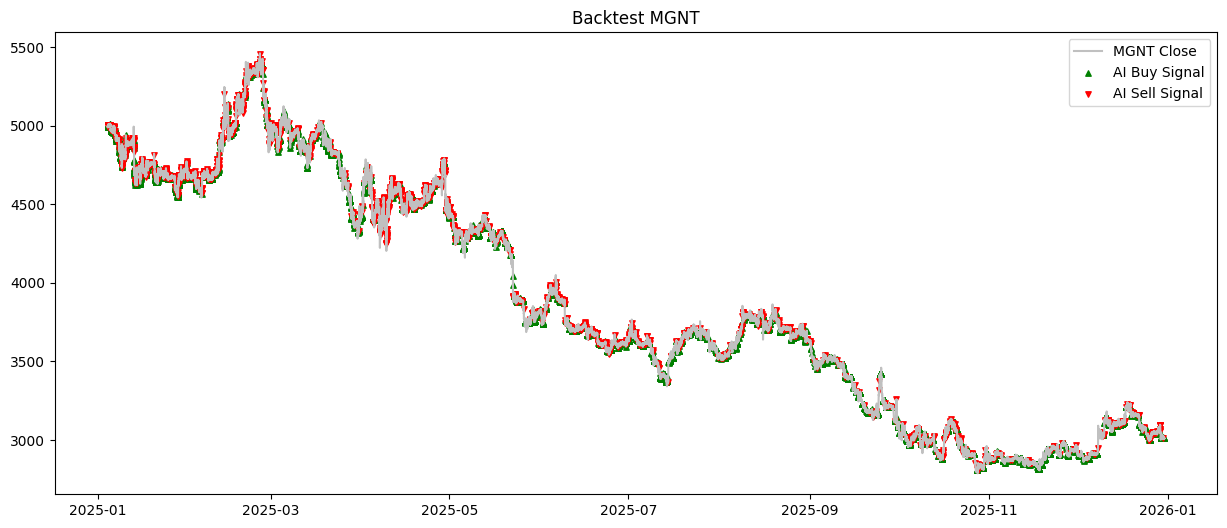

Данных достаточно. Обучение: 48 мес. Проверка составит примерно 12 мес.
Используется оптимизатор legacy.Adam для Mac
Epoch 1/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6336 - accuracy: 0.7022
Epoch 2/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6057 - accuracy: 0.7145
Epoch 3/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5964 - accuracy: 0.7203
Epoch 4/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5888 - accuracy: 0.7255
Epoch 5/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5812 - accuracy: 0.7320
Epoch 6/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5730 - accuracy: 0.7383
Epoch 7/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5641 - accuracy: 0.7456
Epoch 8/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5539 - accuracy: 0.7540
Epoch 9/15
13149/13149 [===================

,Entry Date,Exit Date,Profit %,Type,Duration Days,Duration Months
0,2025-01-04,2025-01-04,-0.03,Signal,0,0.0
1,2025-01-04,2025-01-04,-0.08,Signal,0,0.0
2,2025-01-04,2025-01-04,-0.06,Signal,0,0.0
3,2025-01-04,2025-01-04,-0.05,Signal,0,0.0
4,2025-01-04,2025-01-04,-0.12,Signal,0,0.0
...,...,...,...,...,...,...
835,2025-12-27,2025-12-28,-0.02,Signal,0,0.0
836,2025-12-28,2025-12-29,0.62,Signal,0,0.0
837,2025-12-29,2025-12-29,-0.68,Signal,0,0.0
838,2025-12-29,2025-12-30,0.28,Signal,0,0.0


ИТОГО ПО СТРАТЕГИИ (с безубытком + длительность)
Всего сделок:          840
Win Rate:              41.19%
Общая доходность:      -2.86%
Profit Factor:         0.99
Avg RR Ratio:          1.36
Sharpe Ratio:          -1.36
MDE (стат. порог):     0.13%
Средняя длительность:  0.1 дней (0.00 мес.)
Стат. значимость:      НЕТ (шум)


,Entry Date,Exit Date,Profit %,Type,Duration Days,Duration Months
0,2025-01-04,2025-01-04,-0.03,Signal,0,0.0
1,2025-01-04,2025-01-04,-0.08,Signal,0,0.0
2,2025-01-04,2025-01-04,-0.06,Signal,0,0.0
3,2025-01-04,2025-01-04,-0.05,Signal,0,0.0
4,2025-01-04,2025-01-04,-0.12,Signal,0,0.0
...,...,...,...,...,...,...
835,2025-12-27,2025-12-28,-0.02,Signal,0,0.0
836,2025-12-28,2025-12-29,0.62,Signal,0,0.0
837,2025-12-29,2025-12-29,-0.68,Signal,0,0.0
838,2025-12-29,2025-12-30,0.28,Signal,0,0.0


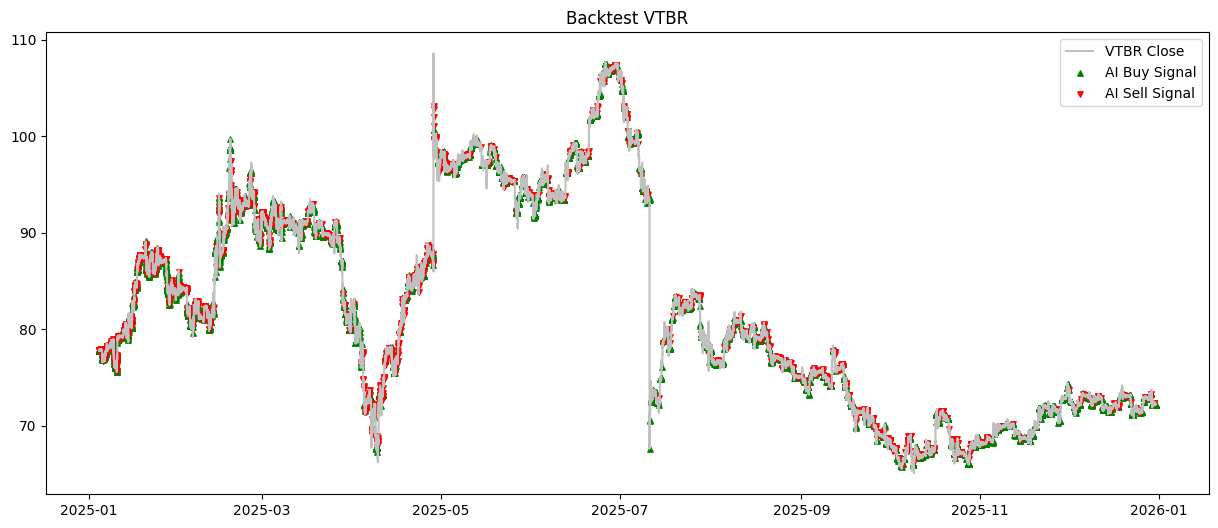

Данных достаточно. Обучение: 48 мес. Проверка составит примерно 12 мес.
Используется оптимизатор legacy.Adam для Mac
Epoch 1/15
13149/13149 [==============================] - 18s 1ms/step - loss: 0.6551 - accuracy: 0.6890
Epoch 2/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6253 - accuracy: 0.7021
Epoch 3/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6151 - accuracy: 0.7100
Epoch 4/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.6063 - accuracy: 0.7168
Epoch 5/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5983 - accuracy: 0.7236
Epoch 6/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5897 - accuracy: 0.7308
Epoch 7/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5803 - accuracy: 0.7383
Epoch 8/15
13149/13149 [==============================] - 17s 1ms/step - loss: 0.5699 - accuracy: 0.7468
Epoch 9/15
13149/13149 [===================

,Entry Date,Exit Date,Profit %,Type,Duration Days,Duration Months
0,2025-01-04,2025-01-04,-0.08,Signal,0,0.0
1,2025-01-04,2025-01-04,-0.03,Signal,0,0.0
2,2025-01-04,2025-01-04,0.09,Signal,0,0.0
3,2025-01-04,2025-01-04,0.18,Signal,0,0.0
4,2025-01-04,2025-01-04,-0.20,Signal,0,0.0
...,...,...,...,...,...,...
790,2025-12-28,2025-12-28,0.16,Signal,0,0.0
791,2025-12-28,2025-12-29,1.29,Signal,0,0.0
792,2025-12-29,2025-12-30,-2.18,Signal,0,0.0
793,2025-12-30,2025-12-30,1.27,Signal,0,0.0


ИТОГО ПО СТРАТЕГИИ (с безубытком + длительность)
Всего сделок:          795
Win Rate:              40.63%
Общая доходность:      -8.61%
Profit Factor:         0.96
Avg RR Ratio:          1.38
Sharpe Ratio:          -1.92
MDE (стат. порог):     0.10%
Средняя длительность:  0.1 дней (0.00 мес.)
Стат. значимость:      НЕТ (шум)


,Entry Date,Exit Date,Profit %,Type,Duration Days,Duration Months
0,2025-01-04,2025-01-04,-0.08,Signal,0,0.0
1,2025-01-04,2025-01-04,-0.03,Signal,0,0.0
2,2025-01-04,2025-01-04,0.09,Signal,0,0.0
3,2025-01-04,2025-01-04,0.18,Signal,0,0.0
4,2025-01-04,2025-01-04,-0.20,Signal,0,0.0
...,...,...,...,...,...,...
790,2025-12-28,2025-12-28,0.16,Signal,0,0.0
791,2025-12-28,2025-12-29,1.29,Signal,0,0.0
792,2025-12-29,2025-12-30,-2.18,Signal,0,0.0
793,2025-12-30,2025-12-30,1.27,Signal,0,0.0


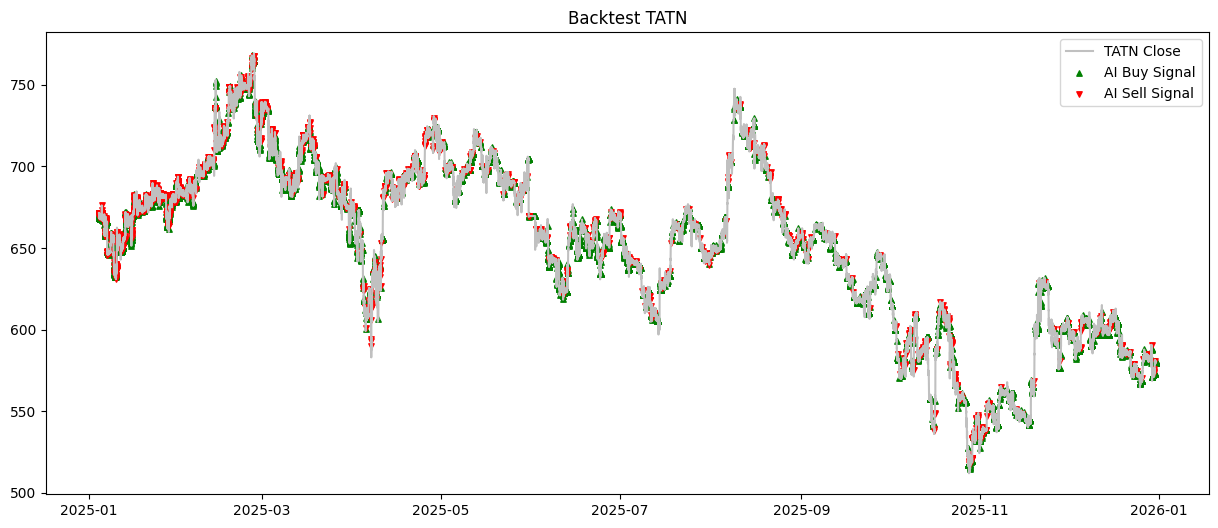

ВНИМАНИЕ: Недостаточно данных! Всего месяцев: 12, нужно минимум: 49
Используется оптимизатор legacy.Adam для Mac
Epoch 1/15
3272/3272 [==============================] - 5s 1ms/step - loss: 0.9044 - accuracy: 0.5314
Epoch 2/15
3272/3272 [==============================] - 5s 1ms/step - loss: 0.8615 - accuracy: 0.5562
Epoch 3/15
3272/3272 [==============================] - 5s 1ms/step - loss: 0.8451 - accuracy: 0.5683
Epoch 4/15
3272/3272 [==============================] - 5s 1ms/step - loss: 0.8317 - accuracy: 0.5811
Epoch 5/15
3272/3272 [==============================] - 5s 1ms/step - loss: 0.8196 - accuracy: 0.5918
Epoch 6/15
3272/3272 [==============================] - 5s 1ms/step - loss: 0.8059 - accuracy: 0.6042
Epoch 7/15
3272/3272 [==============================] - 5s 1ms/step - loss: 0.7907 - accuracy: 0.6159
Epoch 8/15
3272/3272 [==============================] - 5s 1ms/step - loss: 0.7741 - accuracy: 0.6307
Epoch 9/15
3272/3272 [==============================] - 5s 1ms/step - l

ValueError: No objects to concatenate

In [ ]:
for i in tickers_to_test:
    df = pd.read_parquet(f'data/{i}_5min.parquet') 
    df = df[(df['DateTime'] >= '2020-01-01') & (df['DateTime'] < '2026-01-01')]
    df = fill_time_gaps(df, interval_name="5min")
    df = clean_market_data(df)
    df = df.reset_index()

    cols_to_denoise = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in cols_to_denoise:
        df[col] = wavelet_denoise_5m_safe(df[col], daily_window=78)

    df = df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume']).reset_index(drop=True).copy()
    
    # X_all, y_all, dates_all, prices_all = create_tensors(df, window_size=WINDOW_SIZE, alpha=ALPHA)

    final_results = run_backtest_with_fine_tuning(df)

    report_df = analyze_trades(final_results)
    display(report_df)

    report_df_2 = analyze_strategy_performance(final_results, be_trigger=1.0)
    display(report_df_2)

    if not final_results.empty:
        # Визуализация 
        plt.figure(figsize=(15, 6))
        plt.plot(final_results['DateTime'], final_results['Price'], color='silver', label=f'{i} Close')
        
        # Сигналы
        up = final_results[final_results['Predicted'] == 1]
        down = final_results[final_results['Predicted'] == 2]
        
        plt.scatter(up['DateTime'], up['Price'], marker='^', color='green', s=15, label='AI Buy Signal')
        plt.scatter(down['DateTime'], down['Price'], marker='v', color='red', s=15, label='AI Sell Signal')
        
        plt.title(f"Backtest {i}")
        plt.legend()
        plt.show()

In [ ]:
def run_batch_backtest_to_csv(tickers_list, alpha, confidence_threshold,
                              train_months=48, test_months=1, window_size=24,
                              filename='backtest_results.csv',
                              use_wavelet=True, save_plots=False):
    
    summary = []

    for ticker in tickers_list:
        print(f"\n{'='*50}\n📊 Тикер: {ticker}\n{'='*50}")
        try:
            # 1. Загрузка и предобработка
            df = pd.read_parquet(f'data/{ticker}_5min.parquet')
            if 'DateTime' not in df.columns:
                df = df.reset_index() # Если DateTime был индексом, делаем его колонкой
            # Далее фильтрация по датам
            df = df[(df['DateTime'] >= '2020-01-01') & (df['DateTime'] < '2026-01-01')]
            df = fill_time_gaps(df, interval_name="5min")
            df = clean_market_data(df)
            df = df.reset_index(drop=False)
            
            if use_wavelet:
                cols = ['Open', 'High', 'Low', 'Close', 'Volume']
                for col in cols:
                    df[col] = wavelet_denoise_5m_safe(df[col], daily_window=78)
                df = df.dropna(subset=cols).reset_index(drop=True)
                
            if len(df) < 2000:
                print(f"⚠️ {ticker}: недостаточно данных после очистки ({len(df)})")
                continue
                
            # 2. Запуск бэктеста (подхватывает ALPHA и CONFIDENCE_THRESHOLD из глобала)
            preds_df, model_metrics = run_backtest_with_fine_tuning(
                df=df,
                ticker_name=ticker,
                alpha=ALPHA,
                confidence_threshold=CONFIDENCE_THRESHOLD,
                save_plots=save_plots,
                best_config=True  # Для текущей конфигурации сохраняем графики
            )
            
            if preds_df.empty or model_metrics is None:
                print(f"    ⚠️ Бэктест вернул пустые данные")
                continue
                
            # 3. Расчет экономических метрик
            trades_df = analyze_trades(preds_df)
            if trades_df is None or trades_df.empty:
                summary.append({
                    'Ticker': ticker, 'Alpha': ALPHA, 'Confidence_Threshold': CONFIDENCE_THRESHOLD,
                    'Trades_Count': 0, 'Error': 'No trades generated'
                })
                continue
                
            pnls = trades_df['Profit %'] / 100
            n = len(pnls)
            
            win_rate = (pnls > 0).mean() * 100 if n > 0 else 0
            total_ret = pnls.sum() * 100 if n > 0 else 0
            avg_trade = pnls.mean() * 100 if n > 0 else 0
            
            gross_profit = pnls[pnls > 0].sum() if (pnls > 0).any() else 0
            gross_loss = abs(pnls[pnls < 0].sum()) if (pnls < 0).any() else 0
            profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.inf
            
            avg_win = pnls[pnls > 0].mean() if (pnls > 0).any() else 0
            avg_loss = abs(pnls[pnls < 0].mean()) if (pnls < 0).any() else 0
            avg_rr = avg_win / avg_loss if avg_loss != 0 else np.inf
            
            # ✅ Рассчитываем реальную длину бэктест-периода в годах
            if len(preds_df) > 0 and 'DateTime' in preds_df.columns:
                dt_series = pd.to_datetime(preds_df['DateTime'])
                total_days = (dt_series.max() - dt_series.min()).days
                total_years = max(total_days / 365.25, 0.1)  # защита от деления на 0
            else:
                total_years = 1.0

            rf_rate = 0.0  # ✅ Для внутридневных стратегий безрисковую ставку обнуляют
            excess_returns = pnls - rf_rate
            mean_excess = excess_returns.mean()
            std_pnl = pnls.std()

            if n > 1 and std_pnl > 0:
                # ✅ Аннуализация через фактическое число сделок в год
                trades_per_year = n / total_years
                sharpe = (mean_excess / std_pnl) * np.sqrt(trades_per_year)

                # ✅ Sortino: используем только downside deviation
                downside = pnls[pnls < 0]
                downside_std = downside.std() if len(downside) > 0 else std_pnl
                sortino = (mean_excess / downside_std) * np.sqrt(trades_per_year) if downside_std > 0 else 0
            else:
                sharpe, sortino = 0.0, 0.0
            
            mde = 2.8 * pnls.std() / np.sqrt(n) if n > 1 else 0
            stat_sig = abs(pnls.mean()) > mde if n > 1 else False
            
            avg_hold = trades_df['Duration Days'].mean() if 'Duration Days' in trades_df.columns else np.nan
            max_dd = trades_df['Cumulative PnL %'].min() if 'Cumulative PnL %' in trades_df.columns else np.nan
            
            # 4. Формирование итоговой строки
            row = {
                # Идентификаторы
                'Ticker': ticker,
                'Alpha': ALPHA,
                'Confidence_Threshold': CONFIDENCE_THRESHOLD,
                'Wavelet_Used': use_wavelet,
                'Run_Date': datetime.now().strftime('%Y-%m-%d %H:%M'),
                
                # Метрики качества модели (из run_backtest_with_fine_tuning)
                'Model_F1_Macro_Weighted': model_metrics.get('f1_macro_confident_weighted'),
                'Model_Accuracy_Conf': model_metrics.get('accuracy_confident_weighted'),
                'Model_Recall_Buy': model_metrics.get('recall_buy_weighted'),
                'Model_Precision_Buy': model_metrics.get('precision_buy_weighted'),
                'Model_F1_Buy': model_metrics.get('f1_buy_weighted'),
                'Model_Recall_Sell': model_metrics.get('recall_sell_weighted'),
                'Model_Precision_Sell': model_metrics.get('precision_sell_weighted'),
                'Model_F1_Sell': model_metrics.get('f1_sell_weighted'),
                'Total_Samples': model_metrics.get('total_samples'),
                'Confident_Samples': model_metrics.get('total_confident_samples'),
                'Confident_Ratio_%': model_metrics.get('avg_confident_ratio', 0) * 100,
                
                # Торговые метрики
                'Trades_Count': n,
                'Win_Rate_%': round(win_rate, 2),
                'Total_Return_%': round(total_ret, 2),
                'Avg_Trade_%': round(avg_trade, 2),
                'Profit_Factor': round(profit_factor, 3) if profit_factor != np.inf else np.inf,
                'Avg_RR': round(avg_rr, 3) if avg_rr != np.inf else np.inf,
                'Sharpe_Ratio': round(sharpe, 3),
                'Sortino_Ratio': round(sortino, 3),
                'Max_Drawdown_%': round(max_dd, 2) if pd.notna(max_dd) else None,
                'Avg_Hold_Days': round(avg_hold, 2) if pd.notna(avg_hold) else None,
                'MDE_%': round(mde * 100, 3),
                'Statistically_Significant': 'Yes' if stat_sig else 'No',
            }
            
            summary.append(row)
            print(f"    ✅ Сделок: {n}, Sharpe: {sharpe:.2f}, F1(Buy): {row['Model_F1_Buy']:.3f}")
            
        except Exception as e:
            import traceback
            print(f"❌ Ошибка при обработке {ticker}: {e}")
            print(traceback.format_exc())
            summary.append({
                'Ticker': ticker, 'Alpha': ALPHA, 'Confidence_Threshold': CONFIDENCE_THRESHOLD,
                'Error': str(e), 'Trades_Count': 0
            })

    # 5. Сохранение результатов
    if summary:
        res_df = pd.DataFrame(summary)
        # Сортировка: сначала стат. значимые, затем по Sharpe
        if 'Sharpe_Ratio' in res_df.columns and 'Statistically_Significant' in res_df.columns:
            res_df = res_df.sort_values(
                by=['Statistically_Significant', 'Sharpe_Ratio'], 
                ascending=[False, False]
            )
            
        res_df.to_csv(filename, index=False, sep=';', decimal='.', encoding='utf-8-sig')
        print(f"\n📊 Результаты сохранены в '{filename}' ({len(res_df)} строк)")
        
        # Краткий вывод для консоли
        cols_show = ['Ticker', 'Alpha', 'Confidence_Threshold', 'Sharpe_Ratio', 
                     'Model_F1_Buy', 'Win_Rate_%', 'Total_Return_%', 'Statistically_Significant']
        print(f"\n🏆 Топ-5 конфигураций:")
        print(res_df[[c for c in cols_show if c in res_df.columns]].head(5).to_string(index=False))
        return res_df
    else:
        print("⚠️ Нет данных для сохранения.")
        return None

In [102]:
def run_batch_backtest_to_csv_with_TI(tickers_list, alpha, confidence_threshold,
                              train_months=48, test_months=1, window_size=24,
                              filename='backtest_results_v2.csv',
                              use_wavelet=True, save_plots=False):
    
    summary = []

    for ticker in tickers_list:
        print(f"\n{'='*50}\n📊 Тикер: {ticker}\n{'='*50}")
        try:
            # 1. Загрузка
                        # 1. Загрузка и предобработка
            df = pd.read_parquet(f'data/{ticker}_5min.parquet')
            
            # Гарантируем, что DateTime - это колонка (parquet часто сохраняет индекс)
            if df.index.name == 'DateTime' or 'DateTime' in df.index.names:
                df = df.reset_index()
            elif 'DateTime' not in df.columns:
                raise ValueError(f"В данных {ticker} нет колонки DateTime")
                
            df = df[(df['DateTime'] >= '2020-01-01') & (df['DateTime'] < '2026-01-01')]
            
            # 2. Базовая очистка (теперь всегда возвращают DateTime колонкой)
            df = fill_time_gaps(df, interval_name="5min")
            df = clean_market_data(df)
            
            if use_wavelet:
                cols = ['Open', 'High', 'Low', 'Close', 'Volume']
                for col in cols:
                    df[col] = wavelet_denoise_5m_safe(df[col], daily_window=78)
                # dropna безопасен, так как DateTime - колонка, а не индекс
                df = df.dropna(subset=cols).reset_index(drop=True)
                
            # 3. Технические индикаторы (после вейвлета)
            df = add_technical_indicators(df)
            # Снова dropna безопасен для DateTime
            df = df.dropna().reset_index(drop=True)
                
            if len(df) < 2000:
                print(f"⚠️ {ticker}: недостаточно данных после очистки ({len(df)})")
                continue
                
            # 5. Запуск бэктеста нейросети
            preds_df, model_metrics = run_backtest_with_fine_tuning(
                df=df, ticker_name=ticker, alpha=alpha,
                confidence_threshold=confidence_threshold, save_plots=save_plots, best_config=True
            )
            
            if preds_df.empty or model_metrics is None:
                print(f"    ⚠️ Бэктест вернул пустые данные")
                continue
                
            # 6. Анализ сделок
            # Передаем be_trigger=1.0 (безубыток при +1%) и min_hold_bars=6 (30 минут)
            trades_df = analyze_strategy_performance(preds_df, be_trigger=1.0, min_hold_bars=WINDOW_SIZE)
            
            if trades_df is None or trades_df.empty:
                summary.append({'Ticker': ticker, 'Alpha': alpha, 'Confidence_Threshold': confidence_threshold, 'Trades_Count': 0})
                continue
                
            pnls = trades_df['Profit %']
            n = len(pnls)
            
            win_rate = (pnls > 0).mean() * 100
            total_ret = pnls.sum()
            avg_trade = pnls.mean()
            profit_factor = pnls[pnls > 0].sum() / abs(pnls[pnls < 0].sum()) if any(pnls < 0) else np.inf
            avg_rr = pnls[pnls > 0].mean() / abs(pnls[pnls < 0].mean()) if any(pnls < 0) else np.inf
            
            # Расчет Max Drawdown
            max_dd = (trades_df['Cumulative PnL %'] - trades_df['Cumulative PnL %'].cummax()).min()
            
            # Расчет Sharpe
            dt_series = pd.to_datetime(preds_df['DateTime'])
            total_years = max((dt_series.max() - dt_series.min()).days / 365.25, 0.1)
            trades_per_year = n / total_years
            sharpe = (pnls.mean() / pnls.std()) * np.sqrt(trades_per_year) if n > 1 else 0
            
            # MDE
            mde = 2.8 * pnls.std() / np.sqrt(n) if n > 1 else 0
            stat_sig = abs(pnls.mean()) > mde if n > 1 else False
            
            row = {
                'Ticker': ticker, 'Alpha': alpha, 'Confidence_Threshold': confidence_threshold,
                'Wavelet_Used': use_wavelet, 'Run_Date': datetime.now().strftime('%Y-%m-%d %H:%M'),
                'Model_F1_Conf': model_metrics.get('f1_macro_confident_weighted'),
                'Trades_Count': n, 'Win_Rate_%': round(win_rate, 2),
                'Total_Return_%': round(total_ret, 2), 'Avg_Trade_%': round(avg_trade, 2),
                'Profit_Factor': round(profit_factor, 3) if profit_factor != np.inf else np.inf,
                'Sharpe_Ratio': round(sharpe, 3), 'Max_Drawdown_%': round(max_dd, 2),
                'Avg_Hold_Days': round(trades_df['Duration Days'].mean(), 3),
                'MDE_%': round(mde * 100, 3), 'Statistically_Significant': 'Yes' if stat_sig else 'No',
            }
            
            summary.append(row)
            print(f"    ✅ Сделок: {n}, Sharpe: {sharpe:.2f}, PF: {profit_factor:.2f}")
            
        except Exception as e:
            import traceback
            print(f"❌ Ошибка при обработке {ticker}: {e}")
            print(traceback.format_exc())

    # Сохранение
    if summary:
        res_df = pd.DataFrame(summary)
        res_df = res_df.sort_values(by=['Statistically_Significant', 'Sharpe_Ratio'], ascending=[False, False])
        res_df.to_csv(filename, index=False, sep=';', decimal='.', encoding='utf-8-sig')
        print(f"\n📊 Результаты сохранены в '{filename}'")
        return res_df
    else:
        print("⚠️ Нет данных для сохранения.")
        return None

In [ ]:
PARAM_PAIRS = [
    (0.45, 0.5),
    (0.45, 0.6),
    (0.45, 0.7),
    (0.55, 0.5),
    (0.55, 0.6),
    (0.55, 0.7),
    (0.7, 0.5),
    (0.7, 0.6),
    (0.7, 0.7)
]

all_results = []
temp_dir = "results_TI/temp_runs"
os.makedirs(temp_dir, exist_ok=True)

print(f"Запуск перебора по {len(PARAM_PAIRS)} конфигурациям для {len(TICKERS)} тикеров...\n")

for alpha_val, conf_val in PARAM_PAIRS:
    # Обновляем глобальные переменные (в Jupyter это работает напрямую)
    ALPHA = alpha_val
    CONFIDENCE_THRESHOLD = conf_val
    
    print(f"\nКОНФИГУРАЦИЯ: Alpha={ALPHA}, Confidence={CONFIDENCE_THRESHOLD}\n")
    
    temp_file = f"{temp_dir}/run_a{alpha_val}_c{conf_val}.csv"
    
    try:
        res = run_batch_backtest_to_csv_with_TI(
            tickers_list=TICKERS,
            alpha=alpha_val,              
            confidence_threshold=conf_val, 
            train_months=TRAIN_MONTHS,
            test_months=TEST_MONTHS,
            window_size=WINDOW_SIZE,
            filename=temp_file,
            use_wavelet=True,
            save_plots=True
        )
        
        if res is not None and not res.empty:
            all_results.append(res)
            print(f"Прогон завершен. Сделок в таблице: {len(res)}")
        else:
            print("Прогон вернул пустой результат.")
            
    except Exception as e:
        print(f"Ошибка при конфигурации α={alpha_val}, conf={conf_val}: {e}")

# 2. Объединение и финальная обработка
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    
    if 'Statistically_Significant' in final_df.columns:
        final_df['Statistically_Significant_Bool'] = final_df['Statistically_Significant'] == 'Yes'
        final_df = final_df.sort_values(
            by=['Statistically_Significant_Bool', 'Sharpe_Ratio'], 
            ascending=[False, False]
        ).drop(columns=['Statistically_Significant_Bool'])
    else:
        final_df = final_df.sort_values('Sharpe_Ratio', ascending=False)
    
    final_csv = 'results/dissertation_final_metrics_grid.csv'
    final_df.to_csv(final_csv, index=False, sep=';', decimal='.', encoding='utf-8-sig')
    print(f"\nИтоговая таблица сохранена: {final_csv} ({len(final_df)} строк)")
else:
    print("Не получено результатов для сохранения.")

Запуск перебора по 7 конфигурациям для 7 тикеров...


КОНФИГУРАЦИЯ: Alpha=1.5, Confidence=0.6


📊 Тикер: SBER
Обучение SBER на 215899 семплах. Веса классов: {0: 1.3022045296902802, 1: 0.7589223884899168, 2: 1.0935969324438637}
ИТОГО ПО СТРАТЕГИИ (Min Hold: 24 свечей, Безубыток: 1.0%)
Всего сделок:          756
Win Rate:              47.75%
Общая доходность:      3.90%
Max Drawdown:          -28.78%
Profit Factor:         1.03
Avg RR Ratio:          1.08
Средняя длительность:  0.55 дней
    ✅ Сделок: 756, Sharpe: 0.13, PF: 1.03

📊 Тикер: MGNT
Обучение MGNT на 246086 семплах. Веса классов: {0: 1.2624650506605104, 1: 0.7954449217600987, 2: 1.051811389786463}
ИТОГО ПО СТРАТЕГИИ (Min Hold: 24 свечей, Безубыток: 1.0%)
Всего сделок:          544
Win Rate:              46.14%
Общая доходность:      -14.64%
Max Drawdown:          -26.00%
Profit Factor:         0.89
Avg RR Ratio:          1.03
Средняя длительность:  0.33 дней
    ✅ Сделок: 544, Sharpe: -0.83, PF: 0.89

📊 Тикер: VTBR
Обучение VTB

In [94]:
if not final_df.empty:
    best = final_df.iloc[0]
    best_alpha, best_conf = best['Alpha'], best['Confidence_Threshold']
    print(f"Лучшая конфигурация: Alpha={best_alpha}, Confidence={best_conf}")
    print(f"Sharpe: {best['Sharpe_Ratio']:.3f} | F1(Buy): {best['Model_F1_Buy']:.3f} | Значимость: {best['Statistically_Significant']}")
    
    # Запускаем финальный прогон ТОЛЬКО для лучшей пары с save_plots=True
    ALPHA = best_alpha
    CONFIDENCE_THRESHOLD = best_conf
    
    print("Генерация Confusion Matrix для лучшей конфигурации...")
    run_batch_backtest_to_csv_with_TI(
        tickers_list=[best['Ticker']], # Можно указать все тикеры или только лучший
        filename='results/temp_best.csv',
        use_wavelet=True,
        save_plots=True,
        alpha=best_alpha,               # ✅ явно
        confidence_threshold=best_conf
    )
        
    # Очистка временных файлов
    shutil.rmtree(temp_dir, ignore_errors=True)

Лучшая конфигурация: Alpha=1, Confidence=0.75


KeyError: 'Model_F1_Buy'

In [105]:
display(final_df.head(10))

,Ticker,Alpha,Confidence_Threshold,Wavelet_Used,Run_Date,Model_F1_Conf,Trades_Count,Win_Rate_%,Total_Return_%,Avg_Trade_%,Profit_Factor,Sharpe_Ratio,Max_Drawdown_%,Avg_Hold_Days,MDE_%,Statistically_Significant
7,GLDRUB_TOM,1.5,0.70,True,2026-04-22 02:46,None,225,53.33,74.21,0.33,2.354,2.644,-10.88,2.023,24.876,Yes
35,GLDRUB_TOM,2.0,0.85,True,2026-04-22 06:44,None,57,49.12,43.39,0.76,3.590,1.931,-5.77,7.018,78.606,No
14,GLDRUB_TOM,1.5,0.80,True,2026-04-22 03:46,None,92,47.83,48.37,0.53,2.353,1.764,-13.49,5.538,59.430,No
28,GLDRUB_TOM,2.0,0.70,True,2026-04-22 05:36,None,200,48.00,38.09,0.19,1.668,1.555,-10.00,2.094,24.433,No
42,YDEX,3.0,0.90,True,2026-04-22 07:42,None,45,37.78,89.02,1.98,5.112,1.532,-6.66,11.219,256.781,No
43,GLDRUB_TOM,3.0,0.90,True,2026-04-22 07:49,None,35,48.57,69.39,1.98,7.251,1.383,-7.47,13.636,285.904,No
0,GLDRUB_TOM,1.5,0.60,True,2026-04-22 01:19,None,428,50.00,33.73,0.08,1.284,1.227,-10.36,1.153,12.807,No
15,YDEX,1.5,0.80,True,2026-04-22 03:39,None,190,38.42,55.63,0.29,1.553,1.205,-24.20,2.815,48.328,No
1,YDEX,1.5,0.60,True,2026-04-22 01:10,None,699,47.07,52.64,0.08,1.236,1.179,-19.30,0.645,12.700,No
21,GLDRUB_TOM,2.0,0.80,True,2026-04-22 04:41,None,68,52.94,37.43,0.55,2.307,1.177,-9.62,6.166,93.302,No
